### Child Malnutrition Condition Classification

#### Objective

This notebook classifies each child into nutritional condition groups based on MUAC measurements.

## Classification Rules

- Severe Malnutrition
- Moderate Malnutrition
- Good / Normal


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned_data.csv")

print(df.shape)

df.head()

(6785, 11)


,ID,GmpDate,Name_Original,Name,DOB_Original,DOB,MUAC,Age,Age_Months,Age_Diff,Condition
0,581415010001,2017-12-17,ff,ff,2017-12-17,2017-12-17,15.0,84.0,0.00,84.00,Good
1,581415010001,2017-12-28,hdkdj,ff,2017-12-28,2017-12-17,15.0,84.0,0.36,83.64,Good
2,581415010002,2017-12-17,rahim,gg,2017-12-17,2017-12-17,13.0,84.0,0.00,84.00,At Risk
3,581415010002,2017-12-28,ldjjd,gg,2017-12-28,2017-12-17,14.0,84.0,0.36,83.64,Good
4,581415010003,2017-12-28,ifjjfjk,ifjjfjk,2017-12-28,2017-12-28,13.0,84.0,0.00,84.00,At Risk


## MUAC Classification Rules

The following MUAC thresholds are used for nutritional assessment.

- Severe Malnutrition
- Moderate Malnutrition
- At Risk
- Good Nutrition

In [2]:
def classify_condition(muac):

    if muac < 11.5:
        return "Severe"

    elif muac < 12.5:
        return "Moderate"

    elif muac < 13.5:
        return "At Risk"

    else:
        return "Good"

In [3]:
df["Condition"] = df["MUAC"].apply(classify_condition)

df.head()

,ID,GmpDate,Name_Original,Name,DOB_Original,DOB,MUAC,Age,Age_Months,Age_Diff,Condition
0,581415010001,2017-12-17,ff,ff,2017-12-17,2017-12-17,15.0,84.0,0.00,84.00,Good
1,581415010001,2017-12-28,hdkdj,ff,2017-12-28,2017-12-17,15.0,84.0,0.36,83.64,Good
2,581415010002,2017-12-17,rahim,gg,2017-12-17,2017-12-17,13.0,84.0,0.00,84.00,At Risk
3,581415010002,2017-12-28,ldjjd,gg,2017-12-28,2017-12-17,14.0,84.0,0.36,83.64,Good
4,581415010003,2017-12-28,ifjjfjk,ifjjfjk,2017-12-28,2017-12-28,13.0,84.0,0.00,84.00,At Risk


### Condition Distribution

This section analyzes how many children belong to each nutritional condition category.

In [4]:
condition_counts = (
    df["Condition"]
    .value_counts()
)

print(condition_counts)

condition_counts

Condition
Good        3939
At Risk     1651
Moderate     760
Severe       435
Name: count, dtype: int64


Condition
Good        3939
At Risk     1651
Moderate     760
Severe       435
Name: count, dtype: int64

In [5]:
condition_percent = (
    df["Condition"]
    .value_counts(normalize=True)
    * 100
).round(2)

print(condition_percent)

Condition
Good        58.05
At Risk     24.33
Moderate    11.20
Severe       6.41
Name: proportion, dtype: float64


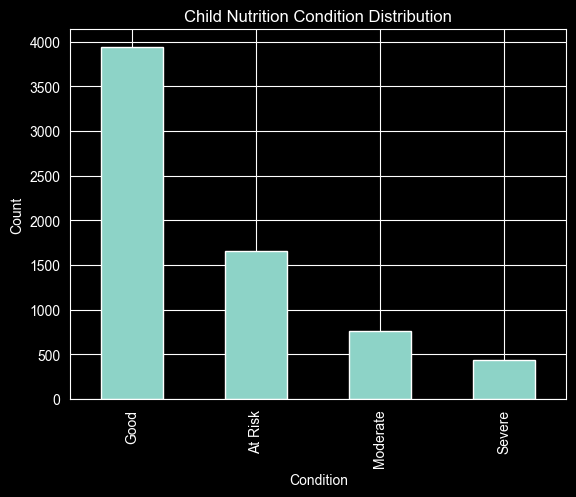

In [6]:
import matplotlib.pyplot as plt

condition_counts.plot(
    kind="bar"
)

plt.title(
    "Child Nutrition Condition Distribution"
)

plt.xlabel(
    "Condition"
)

plt.ylabel(
    "Count"
)

plt.show()

In [7]:
condition_summary = (
    df.groupby("Condition")
    ["MUAC"]
    .agg(
        [
            "count",
            "mean",
            "min",
            "max"
        ]
    )
)

condition_summary

,count,mean,min,max
Condition,,,,
At Risk,1651,12.973574,12.5,13.45
Good,3939,14.778459,13.5,30.00
Moderate,760,12.010618,11.5,12.45
Severe,435,8.938529,5.0,11.40


In [8]:
# Convert ID to string
df["ID"] = df["ID"].astype(str)

# Child ID
child_id = "581415010001"

# Filter child records
child_info = (
    df[df["ID"] == child_id]
    .sort_values("GmpDate")
)

# Columns we want to show
show_columns = [
    "ID",
    "GmpDate",
    "Name_Original",
    "Name",
    "DOB_Original",
    "DOB",
    "MUAC",
    "Age",
    "Age_Months",
    "Age_Diff",
    "Condition"
]

# Keep only existing columns
show_columns = [
    col for col in show_columns
    if col in df.columns
]

# Display result
if len(child_info) == 0:
    print("No records found for this Child ID")
else:
    display(child_info[show_columns])

,ID,GmpDate,Name_Original,Name,DOB_Original,DOB,MUAC,Age,Age_Months,Age_Diff,Condition
0,581415010001,2017-12-17,ff,ff,2017-12-17,2017-12-17,15.0,84.0,0.00,84.00,Good
1,581415010001,2017-12-28,hdkdj,ff,2017-12-28,2017-12-17,15.0,84.0,0.36,83.64,Good


In [9]:
df.to_csv(
    "../data/condition_data.csv",
    index=False
)

print(
    "Condition dataset saved."
)

Condition dataset saved.
